In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [54]:
# Load Training & Testing Data
train_data = pd.read_csv("q2train.csv")
test_data = pd.read_csv("q2test.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

print("\nTraining Data:")
display(train_data.head())

print("\nTesting Data:")
display(test_data.head())

Training data shape: (13603, 4)
Testing data shape: (6700, 4)

Training Data:


,price,bedrooms,living_in_m2,real_bathrooms
0,312000,2,138.42547,2
1,310000,2,105.90942,1
2,320000,2,117.98681,1
3,264500,2,151.43189,2
4,700000,3,341.88304,3



Testing Data:


,price,bedrooms,living_in_m2,real_bathrooms
0,305000,2,76.18046,1
1,498000,3,210.88981,2
2,590000,2,262.91549,2
3,775000,3,159.79316,1
4,350000,2,92.90300,1


In [55]:
# Separate Features and Target
features = ["bedrooms", "living_in_m2", "real_bathrooms"]

X_train, y_train = train_data[features], train_data["price"]
X_test, y_test = test_data[features], test_data["price"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTraining Features:")
display(X_train.head())

print("\nTraining Target:")
display(y_train.head())

X_train shape: (13603, 3)
y_train shape: (13603,)

Training Features:


,bedrooms,living_in_m2,real_bathrooms
0,2,138.42547,2
1,2,105.90942,1
2,2,117.98681,1
3,2,151.43189,2
4,3,341.88304,3



Training Target:


,price
0,312000
1,310000
2,320000
3,264500
4,700000


In [56]:
# Feature Scaling
X_mean, X_std = X_train.mean(), X_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Training Feature Mean:")
display(X_mean)

print("\nTraining Feature Standard Deviation:")
display(X_std)

print("\nScaled Training Data:")
display(X_train_scaled.head())

Training Feature Mean:


,0
bedrooms,2.238624
living_in_m2,181.746181
real_bathrooms,1.678968



Training Feature Standard Deviation:


,0
bedrooms,0.682151
living_in_m2,67.917214
real_bathrooms,0.627218



Scaled Training Data:


,bedrooms,living_in_m2,real_bathrooms
0,-0.349811,-0.637846,0.511835
1,-0.349811,-1.116606,-1.082508
2,-0.349811,-0.938781,-1.082508
3,-0.349811,-0.446342,0.511835
4,1.116139,2.357824,2.106178


In [57]:
# Prepare Matrices for Gradient Descent
X_gd = np.c_[
    np.ones(len(X_train_scaled)),
    X_train_scaled.to_numpy()
]

X_test_gd = np.c_[
    np.ones(len(X_test_scaled)),
    X_test_scaled.to_numpy()
]

y_gd = y_train.to_numpy()

m = len(y_gd)

print("X_gd shape:", X_gd.shape)
print("X_test_gd shape:", X_test_gd.shape)
print("Number of training examples (m):", m)

print("\nFirst 5 rows of X_gd:")
print(X_gd[:5])

X_gd shape: (13603, 4)
X_test_gd shape: (6700, 4)
Number of training examples (m): 13603

First 5 rows of X_gd:
[[ 1.         -0.34981063 -0.63784581  0.51183534]
 [ 1.         -0.34981063 -1.11660588 -1.08250771]
 [ 1.         -0.34981063 -0.93878071 -1.08250771]
 [ 1.         -0.34981063 -0.44634178  0.51183534]
 [ 1.          1.11613947  2.35782432  2.10617838]]


In [58]:
# Gradient Descent Function
def gradient_descent(X, y, alpha, iterations):
    theta = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(iterations):
        error = X @ theta - y

        cost_history.append(
            (1 / (2 * m)) * np.sum(error ** 2)
        )

        theta = theta - alpha * (1 / m) * (X.T @ error)

    return theta, cost_history

print("Gradient Descent function created successfully.")

Gradient Descent function created successfully.


In [59]:
# Train Gradient Descent Model
theta, cost_history = gradient_descent(
    X_gd,
    y_gd,
    alpha=0.1,
    iterations=2000
)

print("Gradient Descent Results")
print("Theta:", theta)
print("Initial Cost:", cost_history[0])
print("Final Cost:", cost_history[-1])

Gradient Descent Results
Theta: [475286.09034772 -24011.33607608 137353.7247737    6810.10559685]
Initial Cost: 134438310122.39546
Final Cost: 13215167967.16469


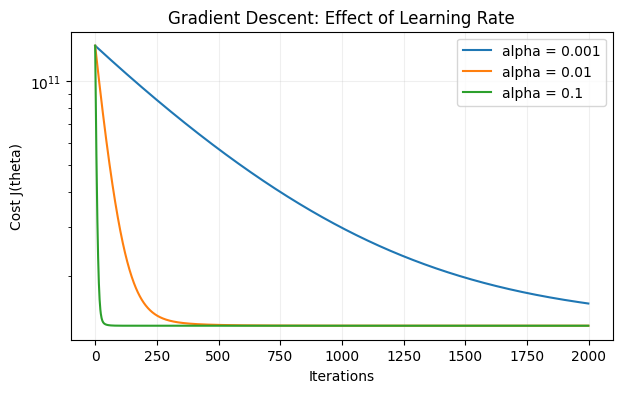

In [60]:
# Learning Rate Comparison Graph
plt.figure(figsize=(7, 4))

for a in [0.001, 0.01, 0.1]:
    _, hist = gradient_descent(
        X_gd,
        y_gd,
        alpha=a,
        iterations=2000
    )

    plt.plot(hist, label=f"alpha = {a}")

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Cost J(theta)")
plt.title("Gradient Descent: Effect of Learning Rate")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [61]:
# Gradient Descent Test Performance
y_pred_gd = X_test_gd @ theta

mse_gd = mean_squared_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent Test Performance")
print("---------------------------------")
print("MSE:", mse_gd)
print("RMSE:", rmse_gd)
print("R² Score:", r2_gd)

print("\nFirst 5 Predictions:")
results_gd = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred_gd[:5]
})

display(results_gd)

Gradient Descent Test Performance
---------------------------------
MSE: 26690568587.087734
RMSE: 163372.48417982672
R² Score: 0.3832662401179463

First 5 Predictions:


,Actual Price,Predicted Price
0,305000,262820.590904
1,498000,510910.940117
2,590000,651325.526126
3,775000,396716.972304
4,350000,296639.751270


In [62]:
# Normal Equation
X_ne = np.c_[
    np.ones(len(X_train)),
    X_train.to_numpy()
]

X_test_ne = np.c_[
    np.ones(len(X_test)),
    X_test.to_numpy()
]

theta_ne = np.linalg.solve(
    X_ne.T @ X_ne,
    X_ne.T @ y_gd
)

print("Normal Equation Results")
print("Theta:", theta_ne)

Normal Equation Results
Theta: [168296.7233972  -35199.4204272    2022.36982931  10857.64447461]


In [63]:
# Normal Equation Test Performance
y_pred_ne = X_test_ne @ theta_ne

mse_ne = mean_squared_error(y_test, y_pred_ne)
rmse_ne = np.sqrt(mse_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print("Normal Equation Test Performance")
print("MSE:", mse_ne)
print("RMSE:", rmse_ne)
print("R² Score:", r2_ne)

print("\nFirst 5 Predictions:")
results_ne = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred_ne[:5]
})

display(results_ne)

Normal Equation Test Performance
MSE: 26690568587.08773
RMSE: 163372.48417982672
R² Score: 0.3832662401179464

First 5 Predictions:


,Actual Price,Predicted Price
0,305000,262820.590904
1,498000,510910.940117
2,590000,651325.526126
3,775000,396716.972304
4,350000,296639.751270


In [64]:
# Check GD vs Normal Equation Parameters Fairly
theta_ne_scaled = np.linalg.solve(
    X_gd.T @ X_gd,
    X_gd.T @ y_gd
)

theta_difference = np.max(
    np.abs(theta - theta_ne_scaled)
)

print("Gradient Descent theta:")
print(theta)

print("\nNormal Equation theta (scaled space):")
print(theta_ne_scaled)

print("\nMaximum theta difference:")
print(theta_difference)

Gradient Descent theta:
[475286.09034772 -24011.33607608 137353.7247737    6810.10559685]

Normal Equation theta (scaled space):
[475286.09034772 -24011.33607608 137353.7247737    6810.10559685]

Maximum theta difference:
2.6193447411060333e-10


In [65]:
# Mean Baseline
y_pred_base = np.full(
    len(y_test),
    y_train.mean()
)

mse_b = mean_squared_error(y_test, y_pred_base)
rmse_b = np.sqrt(mse_b)
r2_b = r2_score(y_test, y_pred_base)

print("Mean Baseline Performance")
print("Mean Training Price:", y_train.mean())
print("MSE:", mse_b)
print("RMSE:", rmse_b)
print("R² Score:", r2_b)

Mean Baseline Performance
Mean Training Price: 475286.0903477174
MSE: 43277310476.65472
RMSE: 208031.99387751566
R² Score: -3.679487940999593e-07


In [66]:
# Final Comparison Table
comparison = pd.DataFrame({
    "Method": [
        "Gradient Descent",
        "Normal Equation",
        "Mean Baseline"
    ],
    "MSE": [
        mse_gd,
        mse_ne,
        mse_b
    ],
    "RMSE": [
        rmse_gd,
        rmse_ne,
        rmse_b
    ],
    "R² Score": [
        r2_gd,
        r2_ne,
        r2_b
    ]
})

print("Final Model Comparison")
display(comparison)

Final Model Comparison


,Method,MSE,RMSE,R² Score
0,Gradient Descent,2.669057e+10,163372.484180,3.832662e-01
1,Normal Equation,2.669057e+10,163372.484180,3.832662e-01
2,Mean Baseline,4.327731e+10,208031.993878,-3.679488e-07


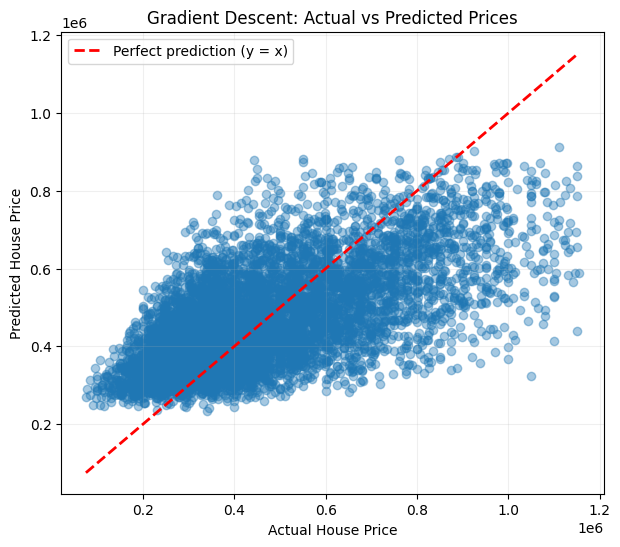

In [67]:
# Actual vs Predicted Graph
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_gd,
    alpha=0.4
)

lo = min(
    y_test.min(),
    y_pred_gd.min()
)

hi = max(
    y_test.max(),
    y_pred_gd.max()
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    linewidth=2,
    color="red",
    label="Perfect prediction (y = x)"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Gradient Descent: Actual vs Predicted Prices")
plt.legend()
plt.grid(alpha=0.2)

plt.show()